# 01 — Chunking & Corpus Prep

**Inputs:**
- `medqa-data/textbooks/en/*.txt` — 18 English medical textbooks (12.85 M words)

**Outputs (saved to `data/processed/`):**
- `chunks.parquet` — every chunk with `chunk_id`, `book_name`, `text`, `n_tokens`, `n_chars`

**Decisions applied here (from [plan.md §0](../plan.md)):**
| # | Setting | Value |
|---|---|---|
| 5 | Chunk size | **400 tokens** (cl100k_base) |
| 5 | Chunk overlap | **80 tokens** (20%) |
| 5 | Min-chunk filter | **30 tokens** (drop boilerplate) |
| 5 | Tokenizer | `tiktoken cl100k_base` |
| 5 | Chunk-ID format | `<book_name>_chunk_<NNNNN>` |

**Why these settings:** 400 tokens fits comfortably under BGE-large's 512-token max; 20% overlap is the 2024-25 medical-RAG standard for boundary-loss protection; cl100k is a uniform sizing metric — 400 cl100k tokens is reliably ≤ 512 BGE tokens.

**Acceptance check (recalibrated 2026-05-03 — see [docs/todo.md §2.1](../docs/todo.md)):**
- Total chunks ≈ **50k–75k** (the original ~36k estimate in `plan.md §0 #5` was mathematically unreachable for a 12.85 M-word corpus with 400/80 config — see math below)
- Mean **300–380 tokens**, max ≤ 450
- Harrison's still ≈ 25 % of corpus by chunk count

**Math behind the recalibration.** Corpus ≈ 16.7 M cl100k tokens (12.85 M words × ≈1.30 tok/word). Each 400-token chunk with 80-token overlap advances ≤ 320 unique tokens, giving a *lower bound* of ~52k chunks even with perfect packing. `RecursiveCharacterTextSplitter` splits at paragraph/sentence boundaries before reaching the 400-token cap, so realistic mean chunk size is ~320–340 tokens → ~65–70k chunks. The 400/80 config itself stays locked (BGE 512-token max ⇒ chunk_size ≤ 400).

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve repo root (notebook may be opened from repo root or notebooks/)
cwd = Path.cwd()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

# Make `src/` importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

TEXTBOOKS_DIR = REPO_ROOT / "medqa-data" / "textbooks" / "en"
OUTPUT_DIR    = REPO_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from src.data.chunker import (
    CHUNK_SIZE_TOKENS,
    CHUNK_OVERLAP_TOKENS,
    MIN_CHUNK_TOKENS,
    TOKENIZER_NAME,
    chunk_textbook,
    chunk_corpus,
)

print(f"Repo root:          {REPO_ROOT}")
print(f"Textbooks dir:      {TEXTBOOKS_DIR}")
print(f"Output dir:         {OUTPUT_DIR}")
print(f"Chunker config:     {CHUNK_SIZE_TOKENS}-token chunks, {CHUNK_OVERLAP_TOKENS}-token overlap, drop < {MIN_CHUNK_TOKENS}")
print(f"Tokenizer:          {TOKENIZER_NAME}")


Repo root:          /Users/rajak/Workstation/Projects/myGitHub/thesis-project
Textbooks dir:      /Users/rajak/Workstation/Projects/myGitHub/thesis-project/medqa-data/textbooks/en
Output dir:         /Users/rajak/Workstation/Projects/myGitHub/thesis-project/data/processed
Chunker config:     400-token chunks, 80-token overlap, drop < 30
Tokenizer:          cl100k_base


## 2. Inventory the corpus

Locate the 18 textbook files and confirm sizes match the EDA snapshot in `data/processed/textbook_stats.parquet` from Notebook 00.

In [2]:
textbook_files = sorted(TEXTBOOKS_DIR.glob("*.txt"))
print(f"Found {len(textbook_files)} textbook files\n")

inventory = pd.DataFrame({
    "book_name":  [fp.stem for fp in textbook_files],
    "size_bytes": [fp.stat().st_size for fp in textbook_files],
}).sort_values("size_bytes", ascending=False).reset_index(drop=True)
inventory["size_mb"] = (inventory["size_bytes"] / 1e6).round(2)
inventory[["book_name", "size_mb"]]


Found 18 textbook files



,book_name,size_mb
0,InternalMed_Harrison,22.38
1,Surgery_Schwartz,11.48
2,Neurology_Adams,8.39
3,Obstentrics_Williams,6.59
4,Gynecology_Novak,5.65
5,Pharmacology_Katzung,5.14
6,Cell_Biology_Alberts,4.90
7,Pathology_Robbins,3.81
8,Immunology_Janeway,3.33
9,Physiology_Levy,3.07


## 3. Smoke test — chunk one small textbook first

Before running on all 18 books, verify the chunker output looks sane on `First_Aid_Step1` (~670 KB, the smallest non-trivial book). Cost: ~1 second of CPU. If the smoke test reveals a bug — wrong token counts, malformed IDs, no overlap — fix it before processing the 12.85 M-word corpus.

In [3]:
smoke_book = "First_Aid_Step1"
smoke_path = TEXTBOOKS_DIR / f"{smoke_book}.txt"
smoke_text = smoke_path.read_text(encoding="utf-8")

%time smoke_df = chunk_textbook(smoke_text, smoke_book)

print(f"\nChunks produced: {len(smoke_df):,}")
print(f"Token stats:     mean={smoke_df.n_tokens.mean():.1f}  median={smoke_df.n_tokens.median():.0f}  "
      f"min={smoke_df.n_tokens.min()}  max={smoke_df.n_tokens.max()}")
print(f"Char stats:      mean={smoke_df.n_chars.mean():.0f}  max={smoke_df.n_chars.max():,}")
print(f"First chunk_id:  {smoke_df.chunk_id.iloc[0]}")
print(f"Last  chunk_id:  {smoke_df.chunk_id.iloc[-1]}")

# Verify the cap holds and nothing leaked under the min-token floor
assert smoke_df.n_tokens.max() <= CHUNK_SIZE_TOKENS + 50, "chunk overflow"
assert smoke_df.n_tokens.min() >= MIN_CHUNK_TOKENS, "small-chunk filter failed"
print("\n✓ smoke checks passed")


CPU times: user 336 ms, sys: 15.8 ms, total: 352 ms
Wall time: 366 ms

Chunks produced: 547
Token stats:     mean=359.4  median=370  min=80  max=399
Char stats:      mean=1394  max=2,039
First chunk_id:  First_Aid_Step1_chunk_00000
Last  chunk_id:  First_Aid_Step1_chunk_00546

✓ smoke checks passed


In [4]:
# Eyeball: print the first ~300 chars of one mid-corpus chunk to confirm
# the recursive splitter respected paragraph/sentence boundaries.
sample_chunk = smoke_df.text.iloc[len(smoke_df) // 2]
print(sample_chunk[:400])
print(f"\n... [{len(sample_chunk)} chars / {smoke_df.n_tokens.iloc[len(smoke_df) // 2]} tokens]")


Choledocholithiasis Presence of gallstone(s) in common bile duct, often leading to elevated ALP, GGT, direct bilirubin, and/or AST/ALT.

Cholecystitis Acute or chronic inflammation of gallbladder. Calculous cholecystitis—most common type; due to gallstone impaction in the cystic duct resulting in inflammation and gallbladder wall thickening (arrows in B ); can produce 2° infection. Acalculous chol

... [1358 chars / 344 tokens]


## 4. Chunk the full corpus

Process all 18 textbooks. Estimated wall time on M1 Pro: ~1–2 minutes (no API calls, pure CPU).

In [5]:
%time chunks_df = chunk_corpus(TEXTBOOKS_DIR)

print(f"\nTotal chunks: {len(chunks_df):,}")
print(f"Books covered: {chunks_df.book_name.nunique()}")
print(f"Token stats: mean={chunks_df.n_tokens.mean():.1f}  median={chunks_df.n_tokens.median():.0f}  "
      f"min={chunks_df.n_tokens.min()}  max={chunks_df.n_tokens.max()}")


CPU times: user 29.8 s, sys: 466 ms, total: 30.3 s
Wall time: 31.1 s

Total chunks: 67,599
Books covered: 18
Token stats: mean=323.9  median=348  min=30  max=402


## 5. Acceptance checks

In [6]:
# (a) Chunk count in expected band — recalibrated 2026-05-03 (see Cell 0 markdown for math)
total = len(chunks_df)
band_ok = 50_000 <= total <= 75_000
print(f"(a) Total chunks: {total:,}  -- expected 50k-75k -- {'✓' if band_ok else '✗'}")

# (b) Mean tokens — splitter typically fills to ~80% of the 400-token cap
mean_tokens = chunks_df.n_tokens.mean()
mean_ok = 300 <= mean_tokens <= 380
print(f"(b) Mean tokens:  {mean_tokens:.1f}  -- expected 300-380 -- {'✓' if mean_ok else '✗'}")

# (c) Max <= 450 tokens (small cushion above the 400 cap for edge cases)
max_tokens = chunks_df.n_tokens.max()
max_ok = max_tokens <= 450
print(f"(c) Max tokens:   {max_tokens}  -- expected <= 450  -- {'✓' if max_ok else '✗'}")

# (d) Harrison's share preserved (~25%)
counts_per_book = chunks_df.book_name.value_counts()
harrison_share = counts_per_book.get("InternalMed_Harrison", 0) / total * 100
harrison_ok = 22.0 <= harrison_share <= 28.0
print(f"(d) Harrison's:   {harrison_share:.2f}%  -- expected 22-28%  -- {'✓' if harrison_ok else '✗'}")

# (e) Chunk IDs are unique
ids_unique = chunks_df.chunk_id.is_unique
print(f"(e) chunk_id unique: {ids_unique}  -- {'✓' if ids_unique else '✗'}")

assert all([band_ok, mean_ok, max_ok, harrison_ok, ids_unique]), "acceptance check failed"
print("\n✓ all acceptance checks passed")


(a) Total chunks: 67,599  -- expected 50k-75k -- ✓
(b) Mean tokens:  323.9  -- expected 300-380 -- ✓
(c) Max tokens:   402  -- expected <= 450  -- ✓
(d) Harrison's:   24.66%  -- expected 22-28%  -- ✓
(e) chunk_id unique: True  -- ✓

✓ all acceptance checks passed


## 6. Per-book chunk count (bar chart)

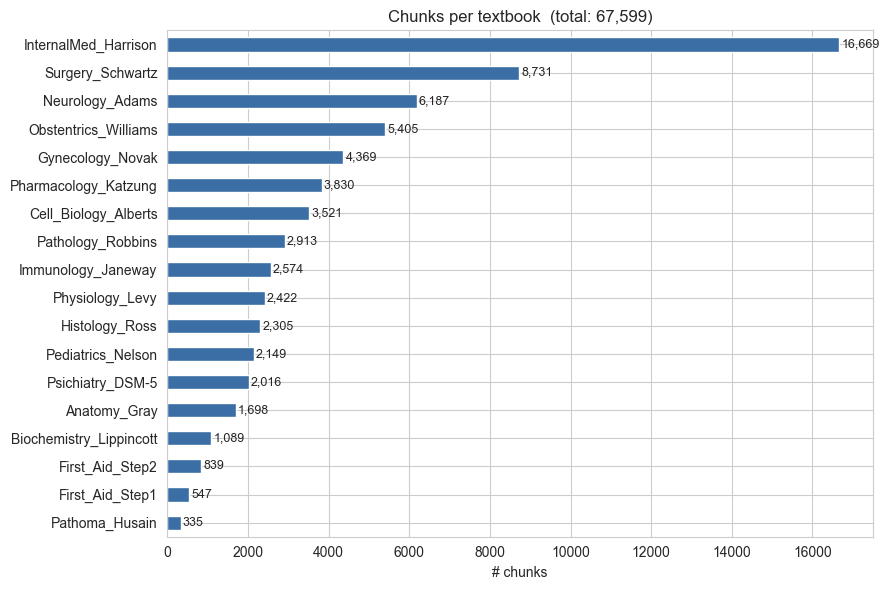

In [7]:
sns.set_style("whitegrid")
counts = chunks_df.book_name.value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
counts.plot(kind="barh", ax=ax, color="#3a6ea5")
ax.set_xlabel("# chunks")
ax.set_ylabel("")
ax.set_title(f"Chunks per textbook  (total: {len(chunks_df):,})")
for i, v in enumerate(counts.values):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


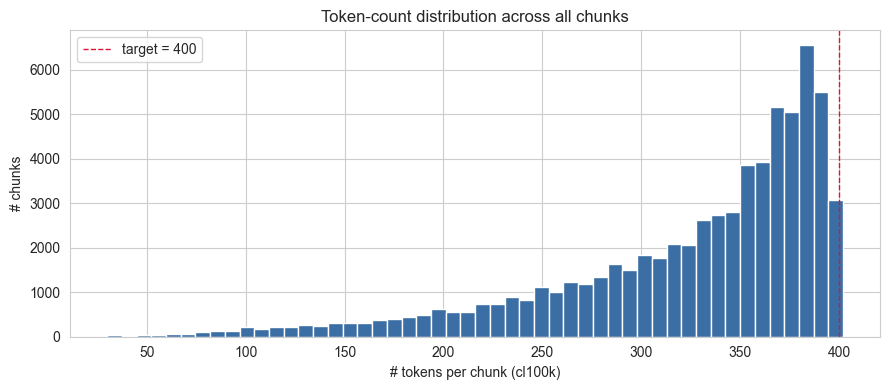

In [8]:
# Token-count distribution across all chunks
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(chunks_df.n_tokens, bins=50, color="#3a6ea5", edgecolor="white")
ax.axvline(CHUNK_SIZE_TOKENS, color="crimson", ls="--", lw=1, label=f"target = {CHUNK_SIZE_TOKENS}")
ax.set_xlabel("# tokens per chunk (cl100k)")
ax.set_ylabel("# chunks")
ax.set_title("Token-count distribution across all chunks")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Save `chunks.parquet`

In [9]:
out_path = OUTPUT_DIR / "chunks.parquet"
chunks_df.to_parquet(out_path, index=False)

written = pd.read_parquet(out_path)
assert len(written) == len(chunks_df)
assert set(written.columns) == {"chunk_id", "book_name", "text", "n_tokens", "n_chars"}

size_mb = out_path.stat().st_size / 1e6
print(f"Saved: {out_path}")
print(f"Rows : {len(written):,}")
print(f"Cols : {list(written.columns)}")
print(f"Size : {size_mb:.1f} MB")


Saved: /Users/rajak/Workstation/Projects/myGitHub/thesis-project/data/processed/chunks.parquet
Rows : 67,599
Cols : ['chunk_id', 'book_name', 'text', 'n_tokens', 'n_chars']
Size : 48.8 MB


---

**Done.** `chunks.parquet` is now ready to be embedded by Notebook 02 (BGE-large → ChromaDB) and indexed by BM25.
